「二季化」検証のためのデータ準備

In [71]:
import os
import numpy as np
import polars as pl
from pathlib import Path
import subprocess
import math
from datetime import datetime, timedelta, date, time
import calendar

JMA_DATA_DIR = Path('/Users/takumi/Projects/MetData/JMA')  # JMAデータ格納ディレクトリのパス

%load_ext autoreload
%autoreload 2
import meteo_lib.core_v4 as cv4
print(cv4.__file__)

#print(isinstance(JMA_DATA_DIR, Path))
      
print("LIB_DATA_DIR     :", cv4.LIB_DATA_DIR)       # 共通マスタ
print("PROJECT_ROOT     :", cv4.PROJECT_ROOT)       # プロジェクトルート
print("PROJECT_DATA_DIR :", cv4.PROJECT_DATA_DIR)   # プロジェクト固有 data
print("OUTPUT_DIR       :", cv4.OUTPUT_DIR)         # 出力
print("JMA_DATA_DIR     :", JMA_DATA_DIR)           # JMAデータ


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/takumi/Projects/meteo_lib/meteo_lib/core_v4.py
LIB_DATA_DIR     : /Users/takumi/Projects/meteo_lib/data
PROJECT_ROOT     : /Users/takumi/Projects/analysis-autumn_length
PROJECT_DATA_DIR : /Users/takumi/Projects/analysis-autumn_length/data
OUTPUT_DIR       : /Users/takumi/Projects/analysis-autumn_length/outputs
JMA_DATA_DIR     : /Users/takumi/Projects/MetData/JMA


In [72]:
# -----------------------------
# Helpers
# -----------------------------
# 期間y0〜y1の平年値を求める
def daily_normals_mmdd(
    lf_in: pl.LazyFrame,
    y0: int,
    y1: int,
    value_col: str,
    qc_ok: tuple[int, ...] = (5, 8),
    drop_leapday: bool = True,
) -> pl.DataFrame:
    qc_col = f"{value_col}_qc_code"
    start = pl.datetime(y0, 1, 1)
    end_exclusive = pl.datetime(y1 + 1, 1, 1)

    out = (
        lf_in
        .select(["datetime", value_col, qc_col])
        .filter(pl.col("datetime").is_between(start, end_exclusive, closed="left"))
        .filter(pl.col(qc_col).is_in(list(qc_ok)))
        .filter(pl.col(value_col).is_not_null())
        .with_columns(pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"))
    )

    if drop_leapday:
        out = out.filter(pl.col("mmdd") != "02-29")

    return (
        out
        .group_by("mmdd")
        .agg([
            pl.col(value_col).mean().alias(f"{value_col}_normal_{y0}_{y1}"),
            pl.col(value_col).count().alias("n_valid"),
        ])
        .sort("mmdd")
        .collect()
    )

def daily_obs_year(
    lf_in: pl.LazyFrame,
    year: int,
    value_col: str,
    qc_ok: tuple[int, ...] = (5, 8),
    drop_leapday: bool = True,
) -> pl.DataFrame:
    qc_col = f"{value_col}_qc_code"
    start = pl.datetime(year, 1, 1)
    end_exclusive = pl.datetime(year + 1, 1, 1)

    out = (
        lf_in
        .select(["datetime", value_col, qc_col])
        .filter(pl.col("datetime").is_between(start, end_exclusive, closed="left"))
        .filter(pl.col(qc_col).is_in(list(qc_ok)))
        .filter(pl.col(value_col).is_not_null())
        .with_columns(pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"))
        .sort("datetime")
    )

    if drop_leapday:
        out = out.filter(pl.col("mmdd") != "02-29")

    return out.collect()


In [73]:
# JMA daily (monthly parquet) -> daily normals / daily anomaly / moving average / annual mean
# - Assumes station_dir contains YYYY-MM.parquet files.
# - Uses QC codes: keep only 5 or 8 (configurable)
# - Requires: polars, matplotlib (only if you plot)

from __future__ import annotations

# -----------------------------
# Settings
# -----------------------------
#station_name = "青森"
#station_id = "b47575"
station_name = "仙台"
station_id = "b47590"

RAW_ROOT = Path("/Volumes/Transcend/projects/MetData/JMA")
station_dir = RAW_ROOT / "daily_monthly" / station_id

# VALUE_COL*　列を読み込む　&　品質情報 QC_OK のみデータとして採用する
VALUE_COL = "temp_mean"
VALUE_COL2 = "temp_max"
VALUE_COL3 = "temp_min"
QC_OK = (5, 8)

# 平年値を求める範囲
NORMAL_Y0, NORMAL_Y1 = 1991, 2020
# 基準となる年
TARGET_YEAR = 1981

MA_WINDOW_DAYS = 5  # e.g. 5 or 7 or 11  # 移動平均の日数

# -----------------------------
# Load (Lazy)
# -----------------------------
# Keep value + qc + datetime (and optionally max/min if you want later)
cols_needed = [
    "datetime",
    VALUE_COL,
    f"{VALUE_COL}_qc_code",
    VALUE_COL2,
    f"{VALUE_COL2}_qc_code",
    VALUE_COL3,
    f"{VALUE_COL3}_qc_code",
]

lf = (
    pl.scan_parquet(str(station_dir / "*.parquet"), extra_columns="ignore")
    .select(cols_needed)
    .with_columns(
        # Make sure datetime is proper type even if some files differ
        pl.col("datetime").cast(pl.Datetime, strict=False)
    )
)

In [75]:
# -----------------------------
# 1) 平年値（MM-DD）
# -----------------------------
norm = daily_normals_mmdd(
    lf,
    NORMAL_Y0,
    NORMAL_Y1,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

# -----------------------------
# 2) 観測（ターゲット年） + 日偏差
# -----------------------------
obs = daily_obs_year(
    lf,
    TARGET_YEAR,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

normal_col = f"{VALUE_COL}_normal_{NORMAL_Y0}_{NORMAL_Y1}"

anom = (
    obs
    .join(norm.select(["mmdd", normal_col]), on="mmdd", how="left")
    .with_columns(
        (pl.col(VALUE_COL) - pl.col(normal_col)).alias(f"{VALUE_COL}_anomaly")
    )
    .sort("datetime")
)

# -----------------------------
# 3) 移動平均（MA_WINDOWS_DAYS日移動平均）
# -----------------------------
anom = anom.with_columns(
    pl.col(f"{VALUE_COL}_anomaly")
    .rolling_mean(window_size=MA_WINDOW_DAYS, min_samples=MA_WINDOW_DAYS)
    .alias(f"{VALUE_COL}_anomaly_ma{MA_WINDOW_DAYS}")
)

# -----------------------------
# 4) 年平均（複数年の時系列）
# -----------------------------
# Example: 1961-2025 annual mean of temp_mean (QC 5/8)
annual = (
    lf
    .select(["datetime", VALUE_COL, f"{VALUE_COL}_qc_code"])
    .filter(pl.col(f"{VALUE_COL}_qc_code").is_in(list(QC_OK)))
    .filter(pl.col(VALUE_COL).is_not_null())
    .with_columns(pl.col("datetime").dt.year().alias("year"))
    .group_by("year")
    .agg([
        pl.col(VALUE_COL).mean().alias(f"{VALUE_COL}_annual_mean"),
        pl.col(VALUE_COL).count().alias("n_valid"),
    ])
    .sort("year")
    .collect()
)

# -----------------------------
# Outputs (print)
# -----------------------------
print("=== 元データ (head) ===")
lf_1981 = lf.filter(pl.col("datetime").dt.year() == 1981) \
  .select(["datetime", "temp_mean", "temp_max", "temp_min"]) \
  .limit(10) \
  .collect()
print(lf_1981)

print("=== 平年値 (head) ===")
print(norm.head(5))

print("\n=== 日偏差+移動平均 (head) ===")
print(anom.select(["datetime", "mmdd", VALUE_COL, normal_col, f"{VALUE_COL}_anomaly", f"{VALUE_COL}_anomaly_ma{MA_WINDOW_DAYS}"]).head(10))

print("\n=== 年平均 (tail) ===")
print(annual.tail(10))

=== 元データ (head) ===
shape: (10, 4)
┌─────────────────────┬───────────┬──────────┬──────────┐
│ datetime            ┆ temp_mean ┆ temp_max ┆ temp_min │
│ ---                 ┆ ---       ┆ ---      ┆ ---      │
│ datetime[μs]        ┆ f32       ┆ f32      ┆ f32      │
╞═════════════════════╪═══════════╪══════════╪══════════╡
│ 1981-01-01 00:00:00 ┆ 1.8       ┆ 4.9      ┆ -2.1     │
│ 1981-01-02 00:00:00 ┆ 2.9       ┆ 7.4      ┆ -0.3     │
│ 1981-01-03 00:00:00 ┆ 1.1       ┆ 2.9      ┆ -0.1     │
│ 1981-01-04 00:00:00 ┆ 1.9       ┆ 5.1      ┆ -1.0     │
│ 1981-01-05 00:00:00 ┆ 0.0       ┆ 3.1      ┆ -2.7     │
│ 1981-01-06 00:00:00 ┆ -0.7      ┆ 2.2      ┆ -3.1     │
│ 1981-01-07 00:00:00 ┆ -1.8      ┆ 0.0      ┆ -3.3     │
│ 1981-01-08 00:00:00 ┆ -0.5      ┆ 2.1      ┆ -4.6     │
│ 1981-01-09 00:00:00 ┆ 3.2       ┆ 6.3      ┆ -1.1     │
│ 1981-01-10 00:00:00 ┆ 1.7       ┆ 5.4      ┆ -1.3     │
└─────────────────────┴───────────┴──────────┴──────────┘
=== 平年値 (head) ===
shape: (5, 3)
┌───

In [76]:
# 1961〜1990年の平年値
norm_1990 = daily_normals_mmdd(
    lf,
    1961,
    1990,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

# 1991〜2020年の平年値
norm_2020 = daily_normals_mmdd(
    lf,
    1991,
    2020,
    value_col=VALUE_COL,
    qc_ok=QC_OK,
    drop_leapday=True,
)

print(norm_1990.head())
print(norm_2020.head())

shape: (5, 3)
┌───────┬────────────────────────────┬─────────┐
│ mmdd  ┆ temp_mean_normal_1961_1990 ┆ n_valid │
│ ---   ┆ ---                        ┆ ---     │
│ str   ┆ f32                        ┆ u32     │
╞═══════╪════════════════════════════╪═════════╡
│ 01-01 ┆ 1.85                       ┆ 30      │
│ 01-02 ┆ 1.696667                   ┆ 30      │
│ 01-03 ┆ 1.21                       ┆ 30      │
│ 01-04 ┆ 1.533333                   ┆ 30      │
│ 01-05 ┆ 1.443333                   ┆ 30      │
└───────┴────────────────────────────┴─────────┘
shape: (5, 3)
┌───────┬────────────────────────────┬─────────┐
│ mmdd  ┆ temp_mean_normal_1991_2020 ┆ n_valid │
│ ---   ┆ ---                        ┆ ---     │
│ str   ┆ f32                        ┆ u32     │
╞═══════╪════════════════════════════╪═════════╡
│ 01-01 ┆ 2.63                       ┆ 30      │
│ 01-02 ┆ 2.923333                   ┆ 30      │
│ 01-03 ┆ 2.73                       ┆ 30      │
│ 01-04 ┆ 2.61                       ┆ 30

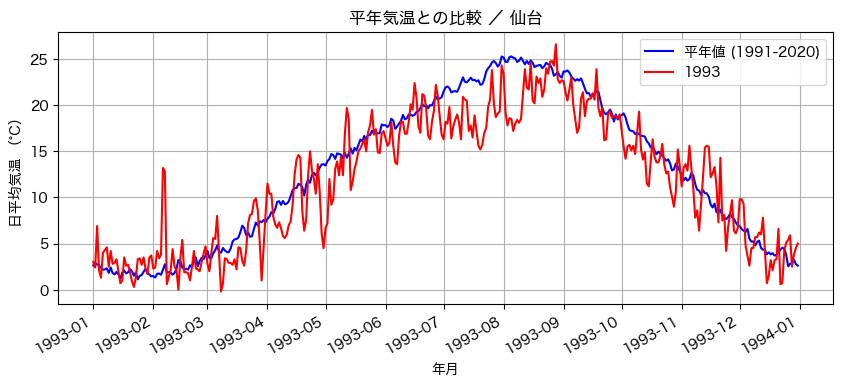

In [98]:
# 平年値と日平均気温の比較

BASE_START, BASE_END = 1991, 2020  # 平年期間（必要に応じて変更）
YEAR = 1993

# YEAR年の日別値（datetime, temp_mean）
df_year = (
    lf
    .filter(pl.col("datetime").dt.year() == YEAR)
    .select([
        pl.col("datetime").alias("date"),
        pl.col("temp_mean").alias(f"temp_{YEAR}"),
        pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"),
    ])
)

# 平年（1991-2020）の "mmddごとの平均"（= 日別平年）
normal = (
    lf
    .filter((pl.col("datetime").dt.year() >= BASE_START) & (pl.col("datetime").dt.year() <= BASE_END))
    .select([
        pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"),
        pl.col("temp_mean"),
    ])
    .group_by("mmdd")
    .agg(pl.col("temp_mean").mean().alias("temp_normal"))
)

# YEAR年の日付に、同じmmddの平年値を付与（うるう日などは欠ける可能性あり）
plot_df = (
    df_year
    .join(normal, on="mmdd", how="left")
    .sort("date")
    .collect()
    .to_pandas()
)

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(plot_df["date"], plot_df["temp_normal"], label=f"平年値 ({BASE_START}-{BASE_END})", color="blue")
ax.plot(plot_df["date"], plot_df[f"temp_{YEAR}"], label=str(YEAR), color="red")

# x軸を「年＋月」表示（毎月表示）
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

#ax.set_title(f"Comparison with Normal Temp at {station_name}")
#ax.set_xlabel("Year-Month")
#ax.set_ylabel("Daily mean temperature")

ax.set_title(f"平年気温との比較 ／ {station_name}")
ax.set_xlabel("年月")
ax.set_ylabel("日平均気温 （°C）")
ax.grid(True)
ax.legend()
fig.autofmt_xdate()  # ラベルが重なるのを回避

plt.savefig(cv4.OUTPUT_DIR / f'平年値との比較_{station_name}_{YEAR}.png')

plt.show()

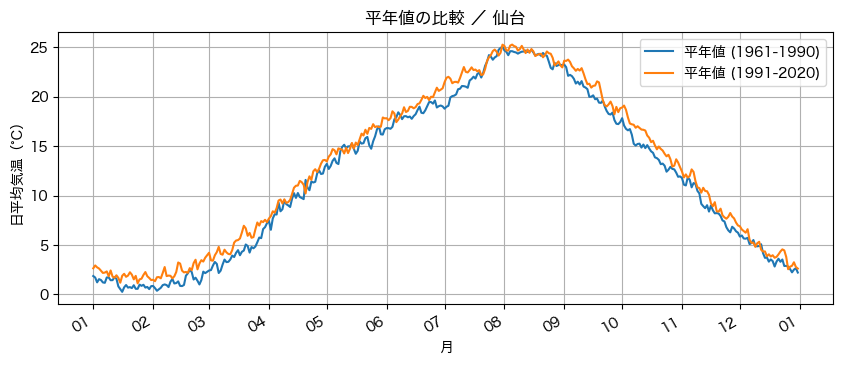

In [79]:
# 平年値同士の比較

BASE1_START, BASE1_END = 1961, 1990
BASE2_START, BASE2_END = 1991, 2020

def daily_normal(lf: pl.LazyFrame, start: int, end: int) -> pd.DataFrame:
    df = (
        lf
        .filter((pl.col("datetime").dt.year() >= start) & (pl.col("datetime").dt.year() <= end))
        .select([
            pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"),
            pl.col("temp_mean"),
        ])
        .group_by("mmdd")
        .agg(pl.col("temp_mean").mean().alias("temp_normal"))
        .sort("mmdd")  # ← これ重要（1月→12月の順に）
        .collect()
        .to_pandas()
    )

    # mmdd -> datetime（年はダミーでOK。うるう日は除外すると安全）
    df = df[df["mmdd"] != "02-29"].copy()
    df["date"] = pd.to_datetime("2000-" + df["mmdd"], format="%Y-%m-%d")

    return df

normal_1 = daily_normal(lf, BASE1_START, BASE1_END)
normal_2 = daily_normal(lf, BASE2_START, BASE2_END)

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(normal_1["date"], normal_1["temp_normal"], label=f"平年値 ({BASE1_START}-{BASE1_END})")
ax.plot(normal_2["date"], normal_2["temp_normal"], label=f"平年値 ({BASE2_START}-{BASE2_END})")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))

ax.set_title(f"平年値の比較 ／ {station_name}")
ax.set_xlabel("月")
ax.set_ylabel("日平均気温（°C）")
ax.grid(True)
ax.legend()
fig.autofmt_xdate()

plt.savefig(cv4.OUTPUT_DIR / f"平年値同士の比較_{station_name}_{BASE1_END}-{BASE2_END}.png")
plt.show()

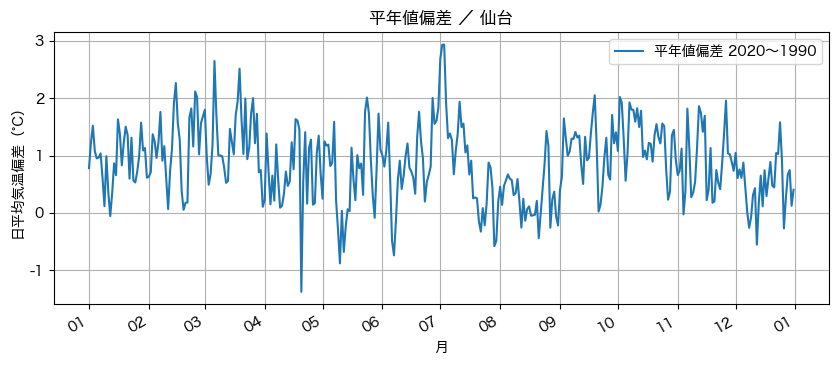

In [80]:
# 平年値の偏差

BASE1_START, BASE1_END = 1961, 1990
BASE2_START, BASE2_END = 1991, 2020

def daily_normal(lf: pl.LazyFrame, start: int, end: int) -> pd.DataFrame:
    df = (
        lf
        .filter((pl.col("datetime").dt.year() >= start) & (pl.col("datetime").dt.year() <= end))
        .select([
            pl.col("datetime").dt.strftime("%m-%d").alias("mmdd"),
            pl.col("temp_mean"),
        ])
        .group_by("mmdd")
        .agg(pl.col("temp_mean").mean().alias("temp_normal"))
        .sort("mmdd")  # ← これ重要（1月→12月の順に）
        .collect()
        .to_pandas()
    )

    # mmdd -> datetime（年はダミーでOK。うるう日は除外すると安全）
    df = df[df["mmdd"] != "02-29"].copy()
    df["date"] = pd.to_datetime("2000-" + df["mmdd"], format="%Y-%m-%d")

    return df

normal_1 = daily_normal(lf, BASE1_START, BASE1_END)
normal_2 = daily_normal(lf, BASE2_START, BASE2_END)

delta_normal = normal_2.copy()
delta_normal["temp_normal"] = normal_2["temp_normal"] - normal_1["temp_normal"]

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(delta_normal["date"], delta_normal["temp_normal"], label=f"平年値偏差 {BASE2_END}〜{BASE1_END}")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))

ax.set_title(f"平年値偏差 ／ {station_name}")
ax.set_xlabel("月")
ax.set_ylabel("日平均気温偏差（°C）")
ax.grid(True)
ax.legend()
fig.autofmt_xdate()

plt.savefig(cv4.OUTPUT_DIR / f"平年値偏差_{station_name}_{BASE1_END}-{BASE2_END}.png")
plt.show()

In [97]:
df = (
    lf
    .filter(
        pl.col("temp_mean").is_not_null(),    # temp_meanがnullの行を削除
        pl.col("temp_mean_qc_code").cast(pl.Int8).is_in([8,5])    # QCコード8，5だけ残す
    ) 
    .with_columns([
        pl.lit(station_id).alias("station_id"),    # station_id, nameを追記
        pl.lit(station_name).alias("station_name"),
    ])
    .select([
        pl.col("datetime").alias("date"),
        pl.col("station_id"),
        pl.col("station_name"),
        pl.col("temp_mean"),
        pl.col("temp_max"),
        pl.col("temp_min"),
    ])
    .collect()
)
df.head()

date,station_id,station_name,temp_mean,temp_max,temp_min
datetime[μs],str,str,f32,f32,f32
1926-10-01 00:00:00,"""b47590""","""仙台""",15.1,18.4,12.7
1926-10-02 00:00:00,"""b47590""","""仙台""",16.0,21.200001,13.5
1926-10-03 00:00:00,"""b47590""","""仙台""",14.8,21.1,10.0
1926-10-04 00:00:00,"""b47590""","""仙台""",14.0,20.4,7.4
1926-10-05 00:00:00,"""b47590""","""仙台""",15.4,20.200001,8.4
